In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [19]:
print("Loading MNIST...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

Loading MNIST...
X shape: (70000, 784)
y shape: (70000,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


In [21]:
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear'],
    'max_iter': [500]
}

In [22]:
base_models = {}
best_params = {}

meta_train_features = []
meta_test_features = []

In [23]:
for digit in range(10):

    print(f"\nTraining model for Digit {digit} vs Rest")

    y_train_binary = (y_train == digit).astype(int)
    y_test_binary = (y_test == digit).astype(int)

    lr = LogisticRegression()

    grid = GridSearchCV(
        estimator=lr,
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=2
    )

    grid.fit(X_train, y_train_binary)

    best_model = grid.best_estimator_

    base_models[digit] = best_model
    best_params[digit] = grid.best_params_

    print("Best Params:", grid.best_params_)

    train_prob = best_model.predict_proba(X_train)[:, 1]
    test_prob = best_model.predict_proba(X_test)[:, 1]

    meta_train_features.append(train_prob)
    meta_test_features.append(test_prob)

    binary_pred = best_model.predict(X_test)

    print(
        "Binary Accuracy:",
        accuracy_score(y_test_binary, binary_pred)
    )


Training model for Digit 0 vs Rest


Best Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9919285714285714

Training model for Digit 1 vs Rest
Best Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9900714285714286

Training model for Digit 2 vs Rest
Best Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9796428571428571

Training model for Digit 3 vs Rest


Exception ignored in: <function ResourceTracker.__del__ at 0x10702dc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Best Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9745

Training model for Digit 4 vs Rest
Best Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9822857142857143

Training model for Digit 5 vs Rest
Best Params: {'C': 1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9731428571428572

Training model for Digit 6 vs Rest
Best Params: {'C': 10, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9858571428571429

Training model for Digit 7 vs Rest
Best Params: {'C': 10, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9838571428571429

Training model for Digit 8 vs Rest


Exception ignored in: <function ResourceTracker.__del__ at 0x102ba1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106c65c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Best Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9575

Training model for Digit 9 vs Rest
Best Params: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Binary Accuracy: 0.9637142857142857


In [24]:
print("\nBest Parameters For Each Model")

for digit, params in best_params.items():
    print(f"Digit {digit}: {params}")


Best Parameters For Each Model
Digit 0: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Digit 1: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Digit 2: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Digit 3: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Digit 4: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Digit 5: {'C': 1, 'max_iter': 500, 'solver': 'liblinear'}
Digit 6: {'C': 10, 'max_iter': 500, 'solver': 'liblinear'}
Digit 7: {'C': 10, 'max_iter': 500, 'solver': 'liblinear'}
Digit 8: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Digit 9: {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}


In [35]:
meta_train_features

[array([9.99860383e-01, 2.93640961e-09, 9.97131068e-01, ...,
        1.71580134e-09, 3.10557807e-09, 2.51795059e-07]),
 array([1.36758269e-23, 2.10552412e-03, 6.21126567e-14, ...,
        9.98675662e-01, 2.87915658e-12, 2.01895427e-19]),
 array([4.82222800e-06, 6.95804630e-05, 7.72538288e-04, ...,
        6.91403178e-04, 1.25079226e-04, 2.36793843e-04]),
 array([9.31377122e-05, 5.77151146e-04, 2.75138060e-03, ...,
        9.98561571e-03, 2.50517568e-07, 1.03016362e-03]),
 array([2.31514420e-06, 1.95746153e-06, 1.44480650e-05, ...,
        5.37169696e-06, 8.94566178e-03, 6.58396485e-01]),
 array([1.38861318e-01, 1.81357922e-04, 2.68071226e-02, ...,
        2.42114743e-03, 3.60450378e-06, 1.05905853e-02]),
 array([8.15049387e-20, 3.46458094e-17, 2.74576712e-24, ...,
        2.05505004e-04, 4.42932956e-34, 6.20674093e-03]),
 array([6.52576002e-48, 9.96062691e-01, 2.43005320e-05, ...,
        5.46105384e-04, 1.03547982e-03, 4.66022168e-01]),
 array([6.68305984e-07, 6.34846968e-02, 8.547299

In [36]:
meta_X_train = np.column_stack(meta_train_features)
meta_X_test = np.column_stack(meta_test_features)

print(meta_X_train.shape)
print(meta_X_test.shape)

(56000, 10)
(14000, 10)


In [38]:
meta_classifier = LogisticRegression(
    max_iter=1000,
    n_jobs=1
)

meta_classifier.fit(
    meta_X_train,
    y_train
)

LogisticRegression(max_iter=1000, n_jobs=1)

In [39]:
y_pred = meta_classifier.predict(
    meta_X_test
)

In [40]:
y_pred

array([7, 3, 1, ..., 6, 2, 8])

In [41]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "\nStacked Model Accuracy:",
    accuracy
)


Stacked Model Accuracy: 0.9142857142857143


In [42]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1381
           1       0.95      0.96      0.96      1575
           2       0.93      0.89      0.91      1398
           3       0.91      0.88      0.90      1428
           4       0.93      0.91      0.92      1365
           5       0.89      0.86      0.87      1263
           6       0.95      0.95      0.95      1375
           7       0.93      0.93      0.93      1459
           8       0.80      0.90      0.85      1365
           9       0.89      0.88      0.88      1391

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.92      0.91      0.91     14000



In [43]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1344    0    2    1    1    2    5    0   22    4]
 [   1 1518    8    8    0    6    2    7   23    2]
 [   5   18 1243   20   13    5   16   20   54    4]
 [   6    3   34 1263    2   42    3   12   49   14]
 [   2    8    7    6 1241    3   10    9   30   49]
 [  13    3    7   42    7 1084   21    9   60   17]
 [  10    3   10    0    5   17 1305    0   25    0]
 [   4    6   16    5   10    3    1 1353   12   49]
 [   9   21   12   26    7   35    8    4 1226   17]
 [   3   10    2   22   47   18    1   42   23 1223]]


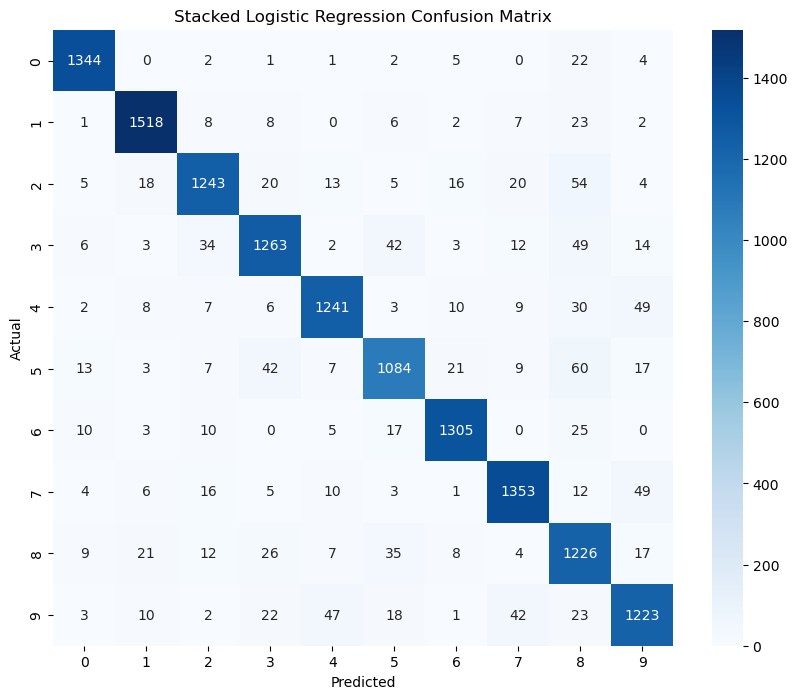

In [44]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Stacked Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()